# Text Segmentation Evaluation Metrics v2 — using `src.utils.text_detection_eval_metrics`
**Author:** Juan Pablo Triana Martinez + Claude Code  
**Date:** 2026-03-24

This notebook is a step-by-step validation of all functions defined in `src/utils/text_detection_eval_metrics.py`.  
It covers **four** evaluation regimes:

| Regime | Function | Input shapes |
|--------|----------|--------------|
| Pixel-level binary | `get_binary_metrics` | logits `B×1×H×W`, targets `B×1×H×W` |
| Pixel-level semantic | `get_semantic_metrics` | logits `B×C×H×W`, targets `B×H×W` |
| Soft binary | `get_soft_metrics` (`is_binary=True`) | logits `B×1×H×W`, targets `B×1×H×W` |
| Soft semantic | `get_soft_metrics` (`is_binary=False`) | logits `B×C×H×W`, targets `B×H×W` |

Because the `.py` functions expect **raw model logits** (before sigmoid / softmax), we derive fake logits from our noisy masks.  
- Binary: `logits = mask * 20 − 10` so `sigmoid(logits)` faithfully reconstructs the binary mask.  
- Semantic: `logits = one_hot(mask) * 10` so `argmax(logits, dim=1)` faithfully reconstructs the class-index mask.

**References:**  
- Damerjian Pieters, V, PhD. (2020). Dice Coefficient vs. IoU in Medical Image Segmentation.  
- Chaurasia, A., & Culurciello, E. (2017). LinkNet. arXiv:1707.03718.

## Notebook Order

1. Load `torch.utils.DataLoaders` for both binary and semantic masks.
2. Define `sample_binary_noise_masks` and `sample_semantic_noise_masks` to simulate imperfect predictions.
3. Import metric functions from `src.utils.text_detection_eval_metrics`.
4. Test **pixel-level binary metrics** (`get_binary_metrics`).
5. Test **pixel-level semantic metrics** (`get_semantic_metrics`), with and without background.
6. Test **soft binary metrics** (`get_soft_metrics`, `is_binary=True`).
7. Test **soft semantic metrics** (`get_soft_metrics`, `is_binary=False`), with and without background.

## 1. Load the `torch.utils.DataLoaders`

In [1]:
from pathlib import Path
import sys
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict

In [2]:
# Resolve the project root and add it to the module search path
working_path = Path().cwd().parent
sys.path.insert(0, str(working_path))

In [3]:
from src.data import get_dataloaders_text_detection
from torchvision import transforms

In [4]:
data_path = working_path / "data"
subset_dataname = "google_collab_seed_86"

### 1.1 Load `binary-text` masks and inspect a single batch

In [5]:
# NOTE: Models evaluated here were trained without input normalization.
# Passing explicit transforms to match the original training setup.
eval_transform = transforms.Compose([
    transforms.Resize((1024, 1024)),
    transforms.ToTensor(),
])

binary_train_dl, binary_val_dl, binary_test_dl = get_dataloaders_text_detection(
    data_path=data_path,
    dataset_name=subset_dataname,
    mask_type="binary-text",
    batch_size=8,
    num_workers=0,
    pin_memory=False,
    new_height=1024,
    new_width=1024,
    train_transform=eval_transform,
    val_transform=eval_transform,
    test_transform=eval_transform,
)

In [6]:
sample_batch_binary = next(iter(binary_train_dl))

batch_binary_imgs  : torch.Tensor = sample_batch_binary[0]
batch_binary_masks : torch.Tensor = sample_batch_binary[1]
batch_binary_meta  : dict         = sample_batch_binary[2]

print(f"Binary images shape : {batch_binary_imgs.shape}")
print(f"Binary masks  shape : {batch_binary_masks.shape}  "
      f"max={batch_binary_masks.max():.0f}  min={batch_binary_masks.min():.0f}  "
      f"dtype={batch_binary_masks.dtype}")

Binary images shape : torch.Size([8, 3, 1024, 1024])
Binary masks  shape : torch.Size([8, 1, 1024, 1024])  max=1  min=0  dtype=torch.float32


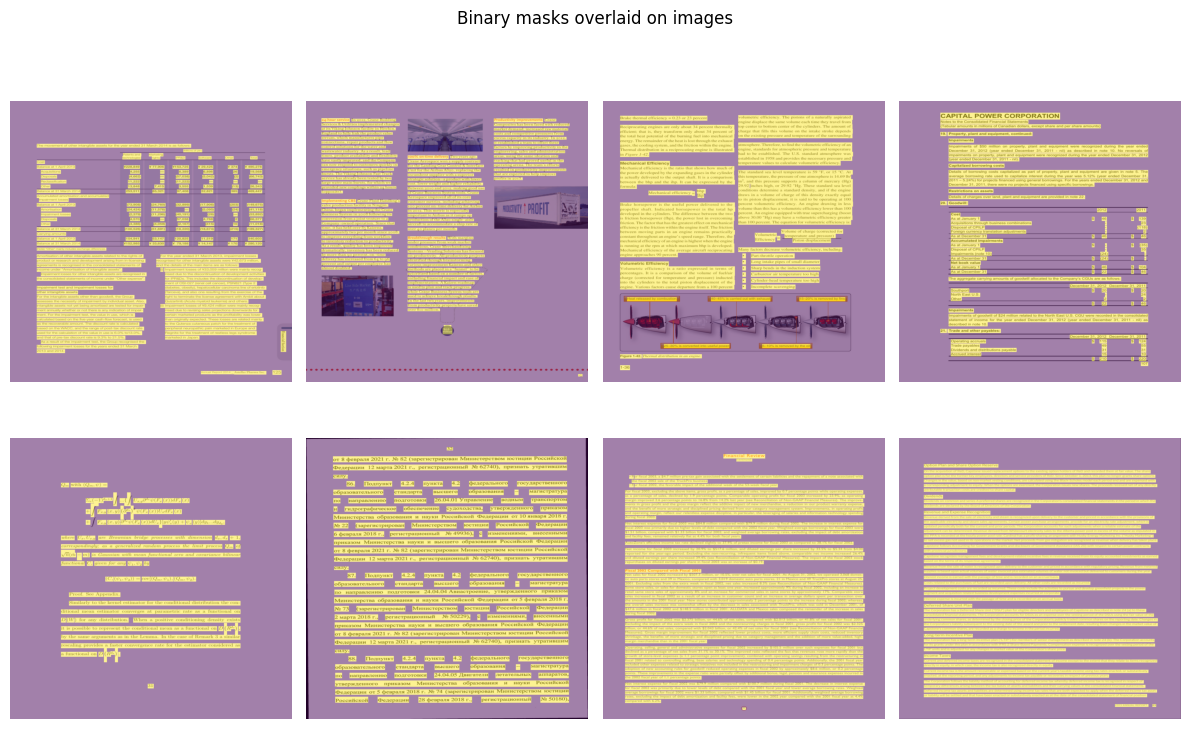

In [7]:
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(12, 8))
for b in range(batch_binary_imgs.shape[0]):
    ax = axs[b // 4, b % 4]
    ax.imshow(batch_binary_imgs[b].permute(1, 2, 0).cpu())
    ax.imshow(batch_binary_masks[b].permute(1, 2, 0).cpu(), alpha=0.5)
    ax.axis("off")
plt.suptitle("Binary masks overlaid on images")
plt.tight_layout()
plt.show()

### 1.2 Load `semantic-layout` masks and inspect a single batch

In [8]:
semantic_train_dl, semantic_val_dl, semantic_test_dl = get_dataloaders_text_detection(
    data_path=data_path,
    dataset_name=subset_dataname,
    mask_type="semantic-layout",
    batch_size=8,
    num_workers=0,
    pin_memory=False,
    new_height=1024,
    new_width=1024,
    train_transform=eval_transform,
    val_transform=eval_transform,
    test_transform=eval_transform,
)

In [9]:
sample_batch_semantic = next(iter(semantic_train_dl))

batch_semantic_imgs  : torch.Tensor = sample_batch_semantic[0]
batch_semantic_masks : torch.Tensor = sample_batch_semantic[1]
batch_semantic_meta  : dict         = sample_batch_semantic[2]

print(f"Semantic images shape : {batch_semantic_imgs.shape}")
print(f"Semantic masks  shape : {batch_semantic_masks.shape}  "
      f"max={batch_semantic_masks.max()}  min={batch_semantic_masks.min()}  "
      f"dtype={batch_semantic_masks.dtype}")

Semantic images shape : torch.Size([8, 3, 1024, 1024])
Semantic masks  shape : torch.Size([8, 1024, 1024])  max=10  min=0  dtype=torch.int64


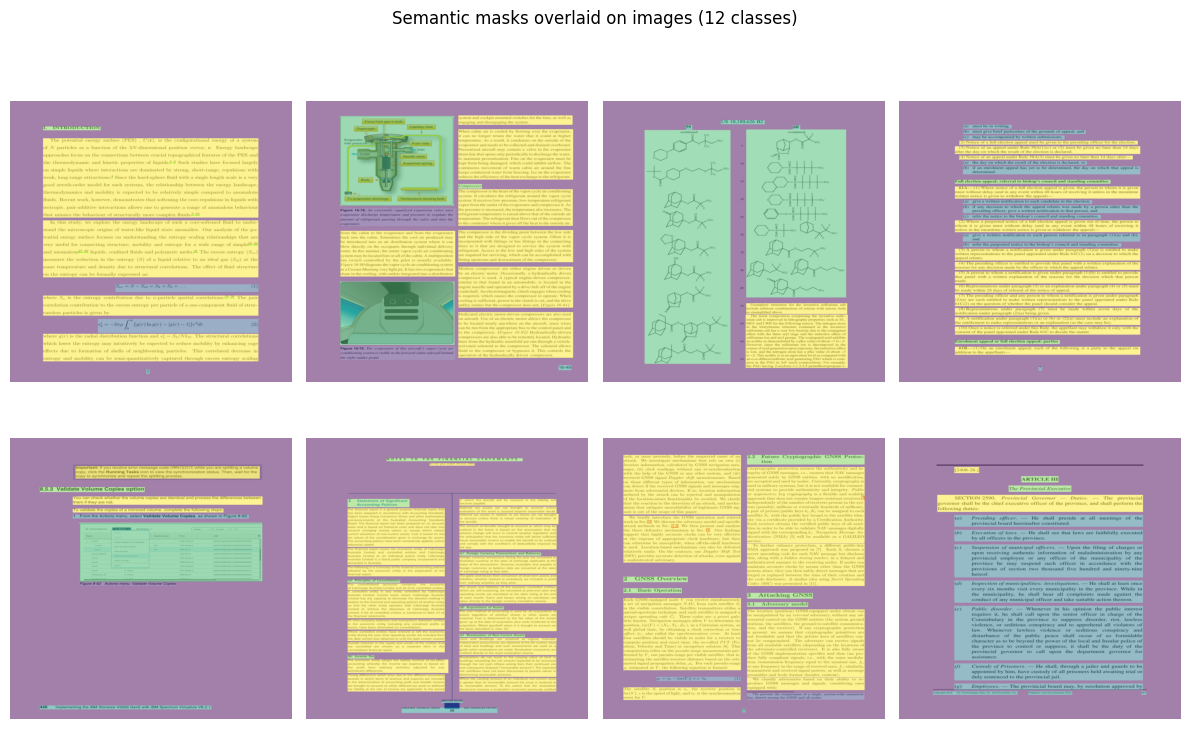

In [10]:
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(12, 8))
for b in range(batch_semantic_imgs.shape[0]):
    ax = axs[b // 4, b % 4]
    ax.imshow(batch_semantic_imgs[b].permute(1, 2, 0).cpu())
    ax.imshow(batch_semantic_masks[b].cpu(), alpha=0.5)
    ax.axis("off")
plt.suptitle("Semantic masks overlaid on images (12 classes)")
plt.tight_layout()
plt.show()

## 2. Create noise functions

We simulate imperfect model predictions by injecting noise into the ground-truth masks.  
The noisy mask acts as a *pseudo-prediction* — good enough to test the metric functions, with a known amount of degradation.

### 2.1 Binary noise — `sample_binary_noise_masks`

In [11]:
def sample_binary_noise_masks(
    batch_binary_masks_shape: Tuple[int],
    prob_one: float = 0.25,
) -> torch.Tensor:
    """
    Generate a random binary mask using Bernoulli sampling.

    Args:
        batch_binary_masks_shape: Shape B x 1 x H x W.
        prob_one: Probability of a pixel being 1.
    Returns:
        torch.Tensor of shape B x 1 x H x W with values in {0, 1}.
    """
    probs = torch.full(batch_binary_masks_shape, prob_one)
    return torch.bernoulli(probs)

In [12]:
batch_binary_noise       = sample_binary_noise_masks(batch_binary_masks.shape)
batch_binary_added_masks = (batch_binary_masks + batch_binary_noise).clamp(max=1.0)

print(f"Binary masks  : {batch_binary_masks.shape}  max={batch_binary_masks.max():.0f}")
print(f"Binary noise  : {batch_binary_noise.shape}  max={batch_binary_noise.max():.0f}")
print(f"Noisy pred    : {batch_binary_added_masks.shape}  max={batch_binary_added_masks.max():.0f}")

Binary masks  : torch.Size([8, 1, 1024, 1024])  max=1
Binary noise  : torch.Size([8, 1, 1024, 1024])  max=1
Noisy pred    : torch.Size([8, 1, 1024, 1024])  max=1


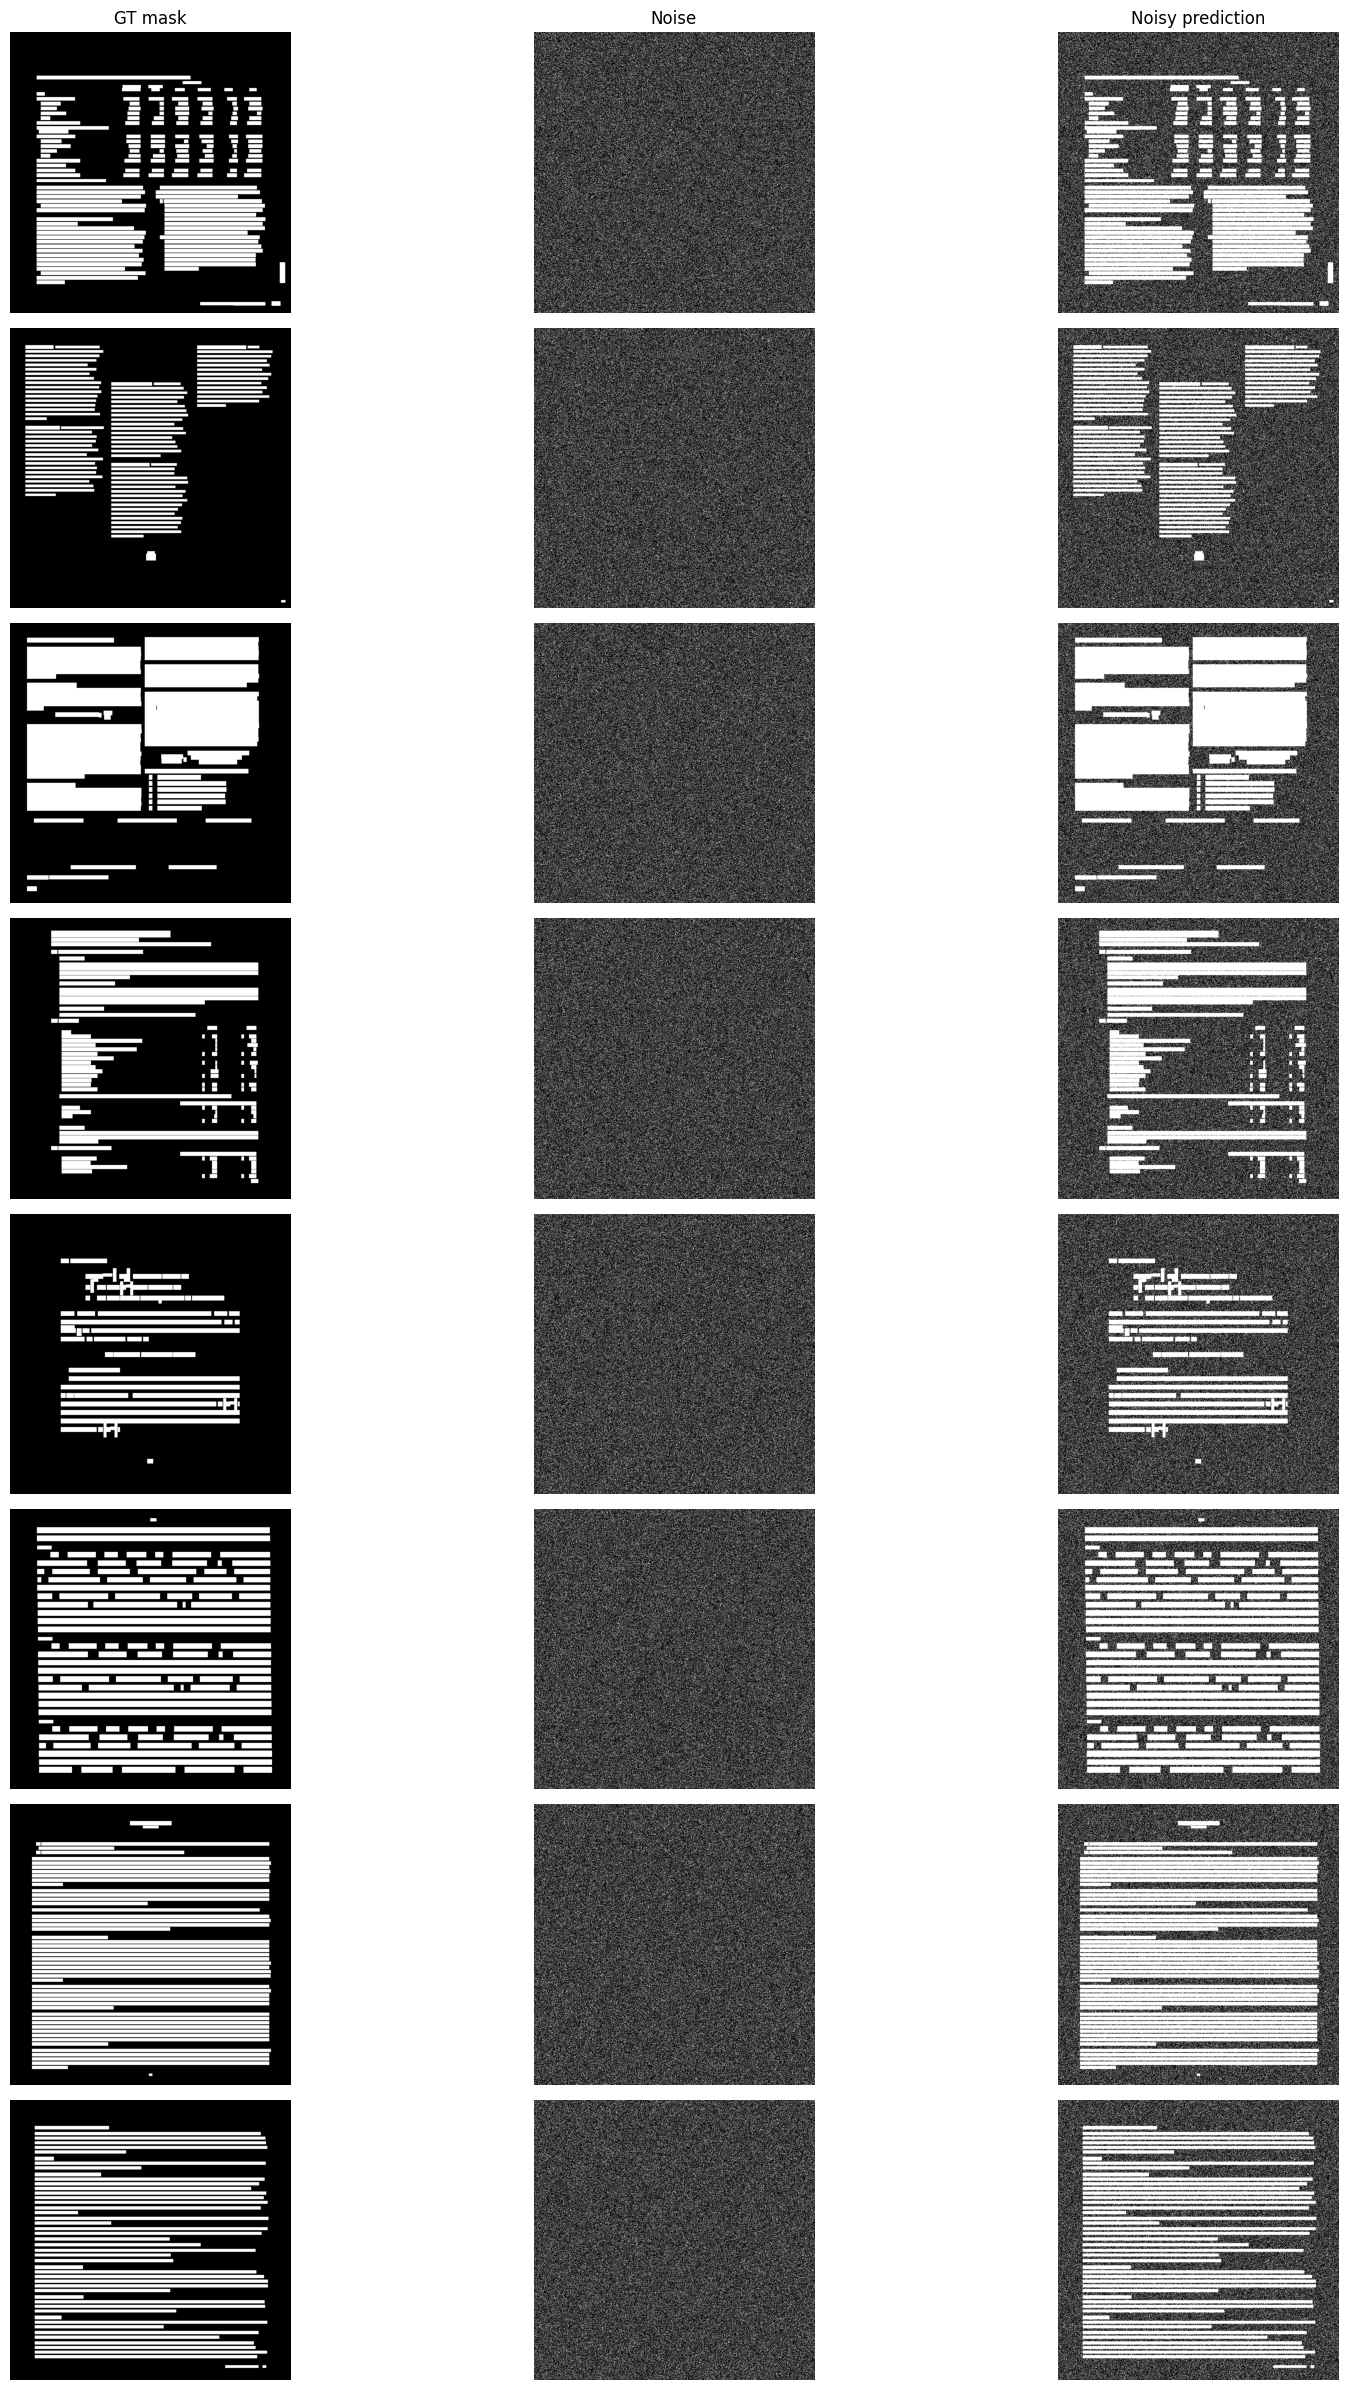

In [13]:
fig, axs = plt.subplots(nrows=batch_binary_masks.shape[0], ncols=3, figsize=(18, 24))
for b in range(batch_binary_masks.shape[0]):
    axs[b, 0].imshow(batch_binary_masks[b].permute(1, 2, 0).cpu(), cmap="gray")
    axs[b, 0].set_title("GT mask" if b == 0 else "")
    axs[b, 0].axis("off")

    axs[b, 1].imshow(batch_binary_noise[b].permute(1, 2, 0).cpu(), cmap="gray")
    axs[b, 1].set_title("Noise" if b == 0 else "")
    axs[b, 1].axis("off")

    axs[b, 2].imshow(batch_binary_added_masks[b].permute(1, 2, 0).cpu(), cmap="gray")
    axs[b, 2].set_title("Noisy prediction" if b == 0 else "")
    axs[b, 2].axis("off")

plt.tight_layout()
plt.show()

### 2.2 Semantic noise — `sample_semantic_noise_masks`

In [14]:
def sample_semantic_noise_masks(
    shape: Tuple[int],
    num_classes: int = 12,
    class_probs: torch.Tensor = None,
) -> torch.Tensor:
    """
    Sample semantic noise masks with class indices in [0, num_classes-1].

    Args:
        shape: (B, H, W).
        num_classes: Total number of classes including background.
        class_probs: Optional 1-D tensor of shape (num_classes,).
                     Uses uniform distribution when None.
    Returns:
        torch.Tensor of shape (B, H, W) with dtype torch.int64.
    """
    B, H, W = shape
    if class_probs is None:
        class_probs = torch.ones(num_classes) / num_classes
    samples = torch.multinomial(class_probs, num_samples=B * H * W, replacement=True)
    return samples.view(B, H, W)

In [15]:
NUM_CLASSES = 12

batch_semantic_noise       = sample_semantic_noise_masks(batch_semantic_masks.shape, num_classes=NUM_CLASSES)
batch_semantic_added_masks = (batch_semantic_masks + batch_semantic_noise).clamp(max=NUM_CLASSES - 1)

print(f"Semantic masks  : {batch_semantic_masks.shape}  max={batch_semantic_masks.max()}  dtype={batch_semantic_masks.dtype}")
print(f"Semantic noise  : {batch_semantic_noise.shape}  max={batch_semantic_noise.max()}  dtype={batch_semantic_noise.dtype}")
print(f"Noisy pred      : {batch_semantic_added_masks.shape}  max={batch_semantic_added_masks.max()}  dtype={batch_semantic_added_masks.dtype}")

Semantic masks  : torch.Size([8, 1024, 1024])  max=10  dtype=torch.int64
Semantic noise  : torch.Size([8, 1024, 1024])  max=11  dtype=torch.int64
Noisy pred      : torch.Size([8, 1024, 1024])  max=11  dtype=torch.int64


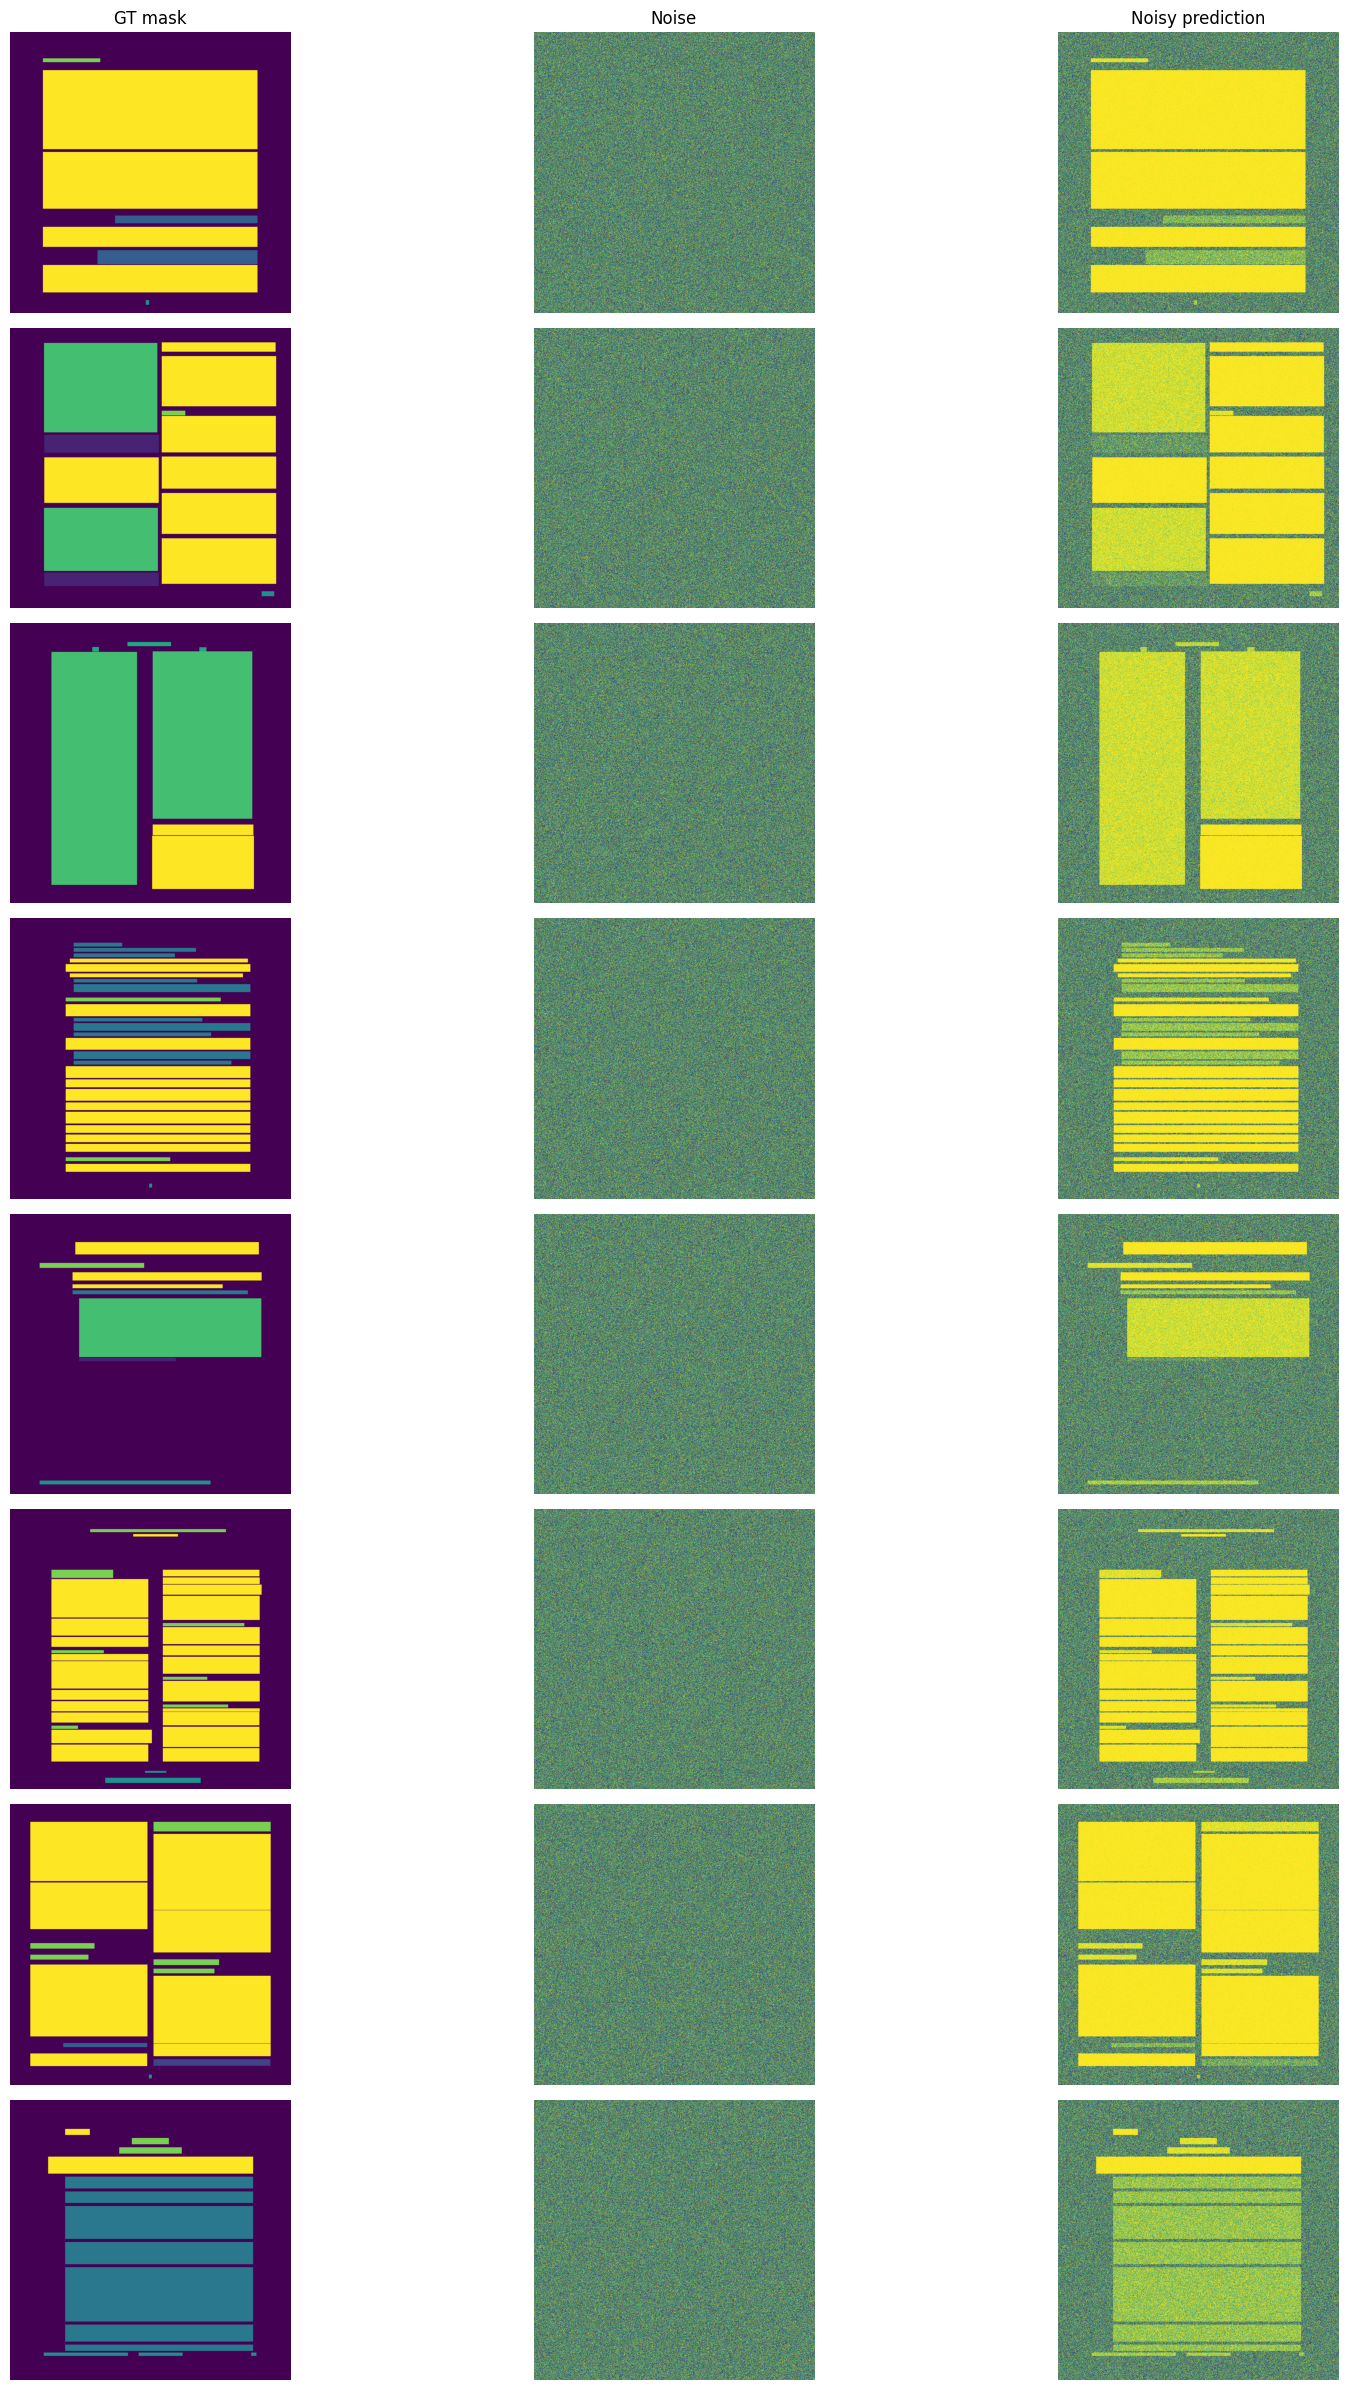

In [16]:
fig, axs = plt.subplots(nrows=batch_semantic_masks.shape[0], ncols=3, figsize=(18, 24))
for b in range(batch_semantic_masks.shape[0]):
    axs[b, 0].imshow(batch_semantic_masks[b].cpu())
    axs[b, 0].set_title("GT mask" if b == 0 else "")
    axs[b, 0].axis("off")

    axs[b, 1].imshow(batch_semantic_noise[b].cpu())
    axs[b, 1].set_title("Noise" if b == 0 else "")
    axs[b, 1].axis("off")

    axs[b, 2].imshow(batch_semantic_added_masks[b].cpu())
    axs[b, 2].set_title("Noisy prediction" if b == 0 else "")
    axs[b, 2].axis("off")

plt.tight_layout()
plt.show()

## 3. Import metric functions from `src.utils`

All three functions are exported from `src/utils/text_detection_eval_metrics.py`.  
They all accept **raw logits** (before activation), not probabilities or class indices.

In [17]:
from src.utils.text_detection_eval_metrics import (
    get_binary_metrics,
    get_semantic_metrics,
    get_soft_metrics,
)

print("Imported: get_binary_metrics, get_semantic_metrics, get_soft_metrics")

Imported: get_binary_metrics, get_semantic_metrics, get_soft_metrics


## 4. Pixel-level binary metrics — `get_binary_metrics`

`get_binary_metrics(logits, targets, threshold)` applies `sigmoid(logits)` internally and thresholds at `threshold`.

**Logit conversion:**  
For a binary mask `m ∈ {0, 1}`, the transformation `logits = m * 20 − 10` gives:
- `m = 1 → logit = +10 → sigmoid = 0.9999 > 0.5 ✓`
- `m = 0 → logit = −10 → sigmoid = 0.0001 < 0.5 ✓`

### 4.1 Convert noisy binary mask → logits and compute metrics

In [18]:
# Derive fake logits from the noisy prediction mask
# Shape: B x 1 x H x W — same as what a trained LinkNet binary head would output
binary_logits = batch_binary_added_masks * 20.0 - 10.0

print(f"binary_logits shape : {binary_logits.shape}")
print(f"binary_logits range : [{binary_logits.min():.1f}, {binary_logits.max():.1f}]")

binary_logits shape : torch.Size([8, 1, 1024, 1024])
binary_logits range : [-10.0, 10.0]


In [19]:
# Get one_show_total_binary_metrics
one_shot_total_binary_metrics = get_binary_metrics(logits=binary_logits,
                                          targets=batch_binary_masks,
                                          threshold=0.5)

print(f"[INFO] This one is how it's gonna be used inside the training loop to obtain pixel hard-metrics")
print(one_shot_total_binary_metrics)

[INFO] This one is how it's gonna be used inside the training loop to obtain pixel hard-metrics
{'accuracy': 0.825259804725647, 'precision': 0.6326203942298889, 'recall': 1.0, 'f1_score': 0.7749754786491394, 'iou_pixel': 0.6326203942298889, 'dice_pixel': 0.7749754786491394}


In [20]:
total_binary_metrics: Dict[str, list] = {}

for b in range(binary_logits.shape[0]):
    # Slice a single image: 1 x 1 x H x W
    logits_b  = binary_logits[b:b+1]
    targets_b = batch_binary_masks[b:b+1]

    metrics = get_binary_metrics(logits_b, targets_b, threshold=0.5)

    for k, v in metrics.items():
        total_binary_metrics.setdefault(k, []).append(v)

# Convert to numpy for easy aggregation
total_binary_metrics = {k: np.array(v) for k, v in total_binary_metrics.items()}
avg_binary_metrics   = {k: v.mean()    for k, v in total_binary_metrics.items()}

print("Average binary pixel metrics:")
for k, v in avg_binary_metrics.items():
    print(f"  {k:<12}: {v:.4f}")

Average binary pixel metrics:
  accuracy    : 0.8253
  precision   : 0.6116
  recall      : 1.0000
  f1_score    : 0.7511
  iou_pixel   : 0.6116
  dice_pixel  : 0.7511


In [21]:
total_binary_metrics

{'accuracy': array([0.81911564, 0.79783249, 0.84922886, 0.80395031, 0.78428078,
        0.85345745, 0.8614397 , 0.83277321]),
 'precision': array([0.60273749, 0.48307082, 0.72467536, 0.52288413, 0.39219737,
        0.73862112, 0.7631228 , 0.66532046]),
 'recall': array([1., 1., 1., 1., 1., 1., 1., 1.]),
 'f1_score': array([0.75213498, 0.65144664, 0.84036136, 0.68670237, 0.56342202,
        0.84966308, 0.86564898, 0.79902989]),
 'iou_pixel': array([0.60273749, 0.48307082, 0.72467536, 0.52288413, 0.39219737,
        0.73862112, 0.7631228 , 0.66532046]),
 'dice_pixel': array([0.75213504, 0.65144676, 0.84036148, 0.68670249, 0.56342208,
        0.84966308, 0.86564904, 0.79902995])}

### 4.2 Plot binary metrics per sample

In [22]:
def plot_metrics_per_sample(metrics_dict: Dict[str, np.ndarray], title: str = "") -> None:
    """Line plot of each metric across the batch dimension."""
    n = len(metrics_dict)
    fig, axs = plt.subplots(nrows=n, ncols=1, figsize=(n, 2 * n))
    if n == 1:
        axs = [axs]
    for ax, (name, values) in zip(axs, metrics_dict.items()):
        ax.plot(values, marker="o")
        ax.set_title(name)
        ax.set_xlabel("Sample index")
        ax.set_ylabel("Value")
        ax.set_ylim(0, 1.05)
    if title:
        fig.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.show()

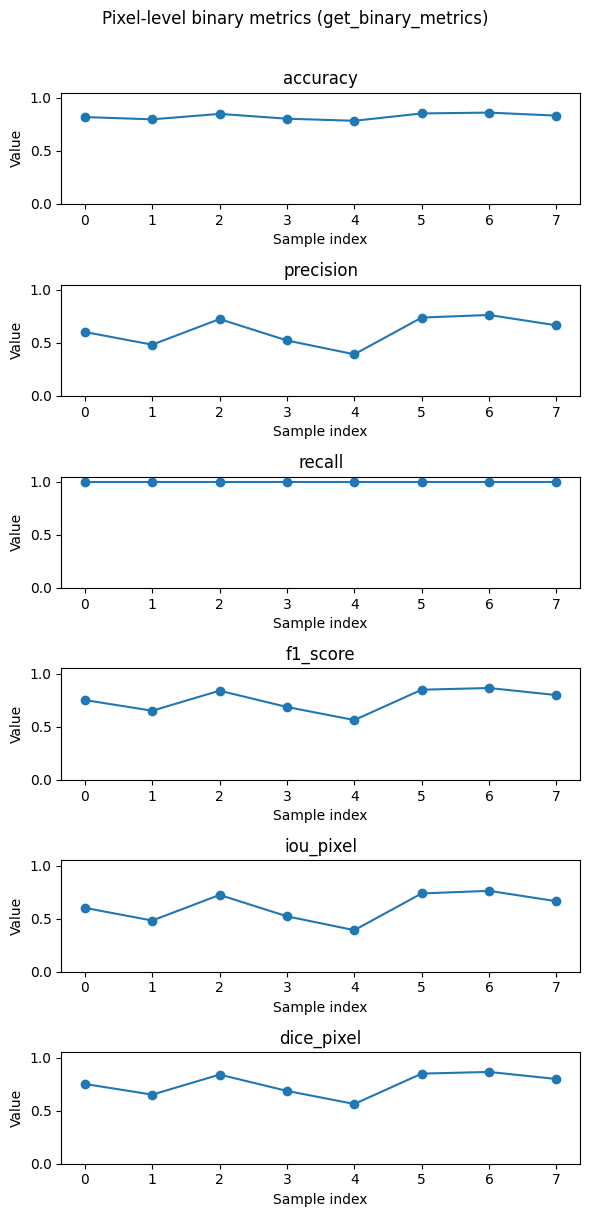

In [23]:
plot_metrics_per_sample(total_binary_metrics, title="Pixel-level binary metrics (get_binary_metrics)")

## 5. Pixel-level semantic metrics — `get_semantic_metrics`

`get_semantic_metrics(logits, targets, num_classes, ignore_background, reduction)` applies `argmax(logits, dim=1)` internally.

**Logit conversion:**  
For class-index mask `m` with shape `B×H×W`, we build a one-hot tensor of shape `B×C×H×W` and scale it by 10:  
```
logits = one_hot(m, C).permute(0,3,1,2).float() * 10
→  argmax(logits, dim=1) == m  ✓
```

We evaluate two variants:
- **With background** (`ignore_background=False`): all 12 classes.
- **Without background** (`ignore_background=True`): classes 1–11 only.

### 5.1 Convert noisy semantic mask → logits

In [24]:
# one_hot expects int64 input
semantic_logits = (
    F.one_hot(batch_semantic_added_masks.long(), num_classes=NUM_CLASSES)
     .permute(0, 3, 1, 2)
     .float()
     * 10.0
)  # Shape: B x NUM_CLASSES x H x W

print(f"semantic_logits shape : {semantic_logits.shape}")
# Sanity-check: argmax should reconstruct the noisy mask exactly
reconstructed = semantic_logits.argmax(dim=1)
assert (reconstructed == batch_semantic_added_masks).all(), "Logit reconstruction failed!"
print("Logit reconstruction check: PASSED")

semantic_logits shape : torch.Size([8, 12, 1024, 1024])
Logit reconstruction check: PASSED


In [26]:
# Get one_show_total_semantic_metrics
one_shot_total_semantic_metrics = get_semantic_metrics(
                    logits=semantic_logits,
                    targets=batch_semantic_masks,
                    num_classes=semantic_logits.shape[1],
                    ignore_background=False,
                    reduction="macro"
                )

print(f"[INFO] This one is how it's gonna be used inside the training loop to obtain pixel hard-metrics")
print(one_shot_total_semantic_metrics)

[INFO] This one is how it's gonna be used inside the training loop to obtain pixel hard-metrics
{'precision': 0.13166646659374237, 'recall': 0.06963475793600082, 'f1_score': 0.09109292179346085, 'iou_pixel': 0.02464018203318119, 'dice_pixel': 0.046555161476135254}


### 5.2 Compute metrics with and without background

In [27]:
total_sem_with_bg:    Dict[str, list] = {}
total_sem_without_bg: Dict[str, list] = {}

for b in range(semantic_logits.shape[0]):
    logits_b  = semantic_logits[b:b+1]                # 1 x C x H x W
    targets_b = batch_semantic_masks[b:b+1].long()    # 1 x H x W

    m_with    = get_semantic_metrics(logits_b, targets_b, num_classes=NUM_CLASSES,
                                     ignore_background=False, reduction="macro")
    m_without = get_semantic_metrics(logits_b, targets_b, num_classes=NUM_CLASSES,
                                     ignore_background=True,  reduction="macro")

    for k, v in m_with.items():
        total_sem_with_bg.setdefault(k, []).append(v)
    for k, v in m_without.items():
        total_sem_without_bg.setdefault(k, []).append(v)

total_sem_with_bg    = {k: np.array(v, dtype=np.float32) for k, v in total_sem_with_bg.items()}
total_sem_without_bg = {k: np.array(v, dtype=np.float32) for k, v in total_sem_without_bg.items()}

print("Average semantic metrics — WITH background:")
for k, v in total_sem_with_bg.items():
    print(f"  {k:<12}: {v.mean():.4f}")

print("\nAverage semantic metrics — WITHOUT background:")
for k, v in total_sem_without_bg.items():
    print(f"  {k:<12}: {v.mean():.4f}")

Average semantic metrics â€” WITH background:
  precision   : 0.1280
  recall      : 0.0353
  f1_score    : 0.0548
  iou_pixel   : 0.0183
  dice_pixel  : 0.0342

Average semantic metrics â€” WITHOUT background:
  precision   : 0.0487
  recall      : 0.0309
  f1_score    : 0.0361
  iou_pixel   : 0.0124
  dice_pixel  : 0.0234


### 5.3 Plot semantic metrics per sample

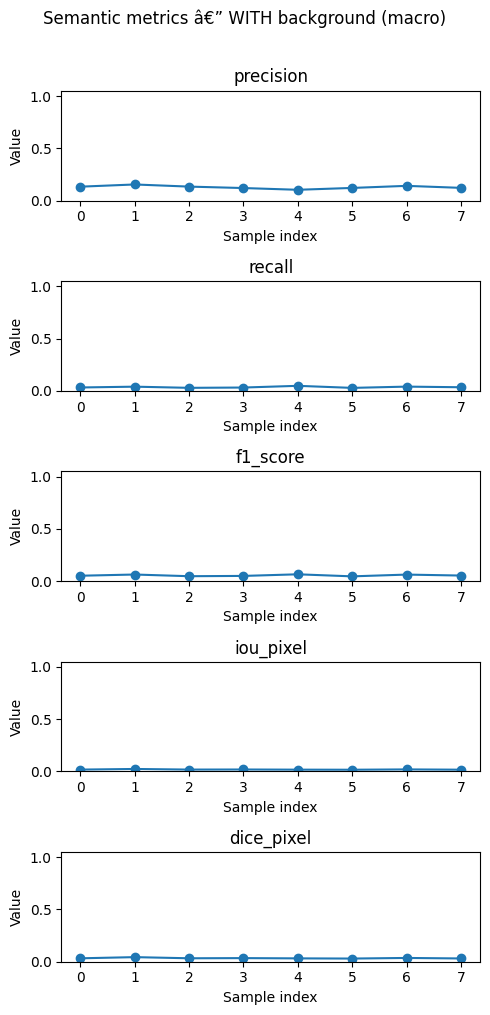

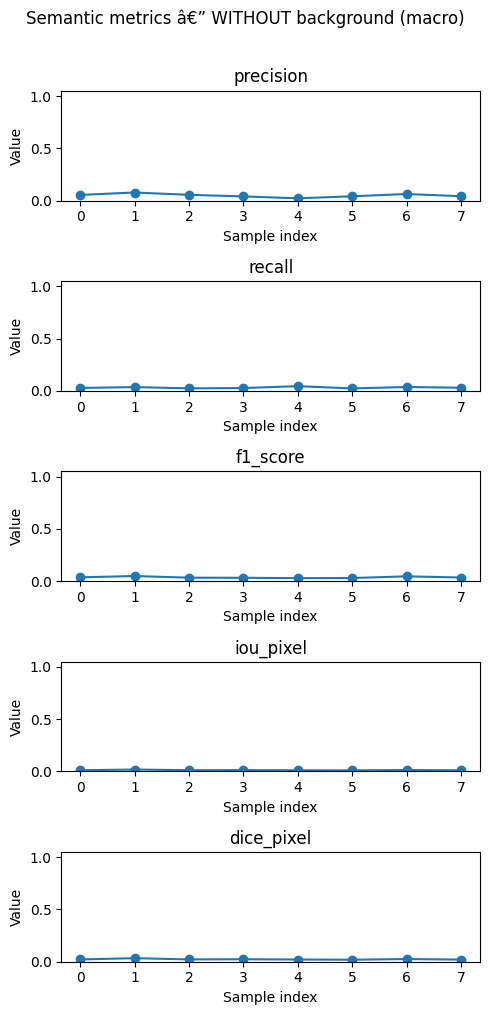

In [28]:
plot_metrics_per_sample(total_sem_with_bg,    title="Semantic metrics — WITH background (macro)")
plot_metrics_per_sample(total_sem_without_bg, title="Semantic metrics — WITHOUT background (macro)")

## 6. Soft binary metrics — `get_soft_metrics(is_binary=True)`

`get_soft_metrics(logits, targets, smooth, is_binary=True)` evaluates at the **soft pixel-level**:

```python
binary_soft_metrics = get_soft_metrics(logits=binary_logits,
                                           targets=batch_binary_masks,
                                           smooth=1,
                                           is_binary=True,
                                           ignore_background=False)
```

In [29]:
binary_logits.shape

torch.Size([8, 1, 1024, 1024])

In [30]:
get_binary_metrics(logits=binary_logits,
                   targets=batch_binary_masks)

{'accuracy': 0.825259804725647,
 'precision': 0.6326203942298889,
 'recall': 1.0,
 'f1_score': 0.7749754786491394,
 'iou_pixel': 0.6326203942298889,
 'dice_pixel': 0.7749754786491394}

### 6.1 Compute soft metrics per batch

In [31]:
binary_soft_metrics = get_soft_metrics(logits=binary_logits,
                                           targets=batch_binary_masks,
                                           smooth=1e-7,
                                           is_binary=True,
                                           ignore_background=False)

In [32]:
binary_soft_metrics

{'IoU_region': tensor(0.6115), 'DsC_region': tensor(0.7510)}

## 7. Soft semantic metrics — `get_soft_metrics(is_binary=False)`

```python
semantic_soft_metrics = get_soft_metrics(logits=semantic_logits,
                                           targets=batch_semantic_masks,
                                           smooth=1,
                                           is_binary=False,
                                           ignore_background=False)
```

```python
semantic_soft_metrics = get_soft_metrics(logits=semantic_logits,
                                           targets=batch_semantic_masks,
                                           smooth=1,
                                           is_binary=False,
                                           ignore_background=True)
```
We reuse `semantic_logits` already built in Section 5.

In [33]:
semantic_logits.shape

torch.Size([8, 12, 1024, 1024])

In [34]:
F.one_hot(batch_semantic_masks, num_classes=12).permute(0, 3, 1, 2).shape

torch.Size([8, 12, 1024, 1024])

In [35]:
semantic_soft_metrics = get_soft_metrics(logits=semantic_logits,
                                           targets=F.one_hot(batch_semantic_masks, num_classes=12).permute(0, 3, 1, 2),
                                           smooth=1e-7,
                                           is_binary=False,
                                           ignore_background=False)

In [36]:
semantic_soft_metrics

{'IoU_class_0': tensor(0.0830),
 'DsC_class_0': tensor(0.1532),
 'IoU_class_1': tensor(0.0068),
 'DsC_class_1': tensor(0.0130),
 'IoU_class_2': tensor(0.0024),
 'DsC_class_2': tensor(0.0046),
 'IoU_class_3': tensor(0.0068),
 'DsC_class_3': tensor(0.0130),
 'IoU_class_4': tensor(0.0170),
 'DsC_class_4': tensor(0.0320),
 'IoU_class_5': tensor(0.0035),
 'DsC_class_5': tensor(0.0070),
 'IoU_class_6': tensor(0.0008),
 'DsC_class_6': tensor(0.0017),
 'IoU_class_7': tensor(0.0257),
 'DsC_class_7': tensor(0.0480),
 'IoU_class_8': tensor(0.0130),
 'DsC_class_8': tensor(0.0253),
 'IoU_class_9': tensor(0.),
 'DsC_class_9': tensor(1.7448e-12),
 'IoU_class_10': tensor(0.0602),
 'DsC_class_10': tensor(0.1129),
 'IoU_class_11': tensor(0.),
 'DsC_class_11': tensor(2.5637e-13),
 'IoU_region': tensor(0.0183),
 'DsC_region': tensor(0.0342)}

In [37]:
semantic_soft_metrics = get_soft_metrics(logits=semantic_logits,
                                           targets=F.one_hot(batch_semantic_masks, num_classes=12).permute(0, 3, 1, 2),
                                           smooth=1e-7,
                                           is_binary=False,
                                           ignore_background=True)

In [38]:
semantic_soft_metrics

{'IoU_class_1': tensor(0.0068),
 'DsC_class_1': tensor(0.0130),
 'IoU_class_2': tensor(0.0024),
 'DsC_class_2': tensor(0.0046),
 'IoU_class_3': tensor(0.0068),
 'DsC_class_3': tensor(0.0130),
 'IoU_class_4': tensor(0.0170),
 'DsC_class_4': tensor(0.0320),
 'IoU_class_5': tensor(0.0035),
 'DsC_class_5': tensor(0.0070),
 'IoU_class_6': tensor(0.0008),
 'DsC_class_6': tensor(0.0017),
 'IoU_class_7': tensor(0.0257),
 'DsC_class_7': tensor(0.0480),
 'IoU_class_8': tensor(0.0130),
 'DsC_class_8': tensor(0.0253),
 'IoU_class_9': tensor(0.),
 'DsC_class_9': tensor(1.7448e-12),
 'IoU_class_10': tensor(0.0602),
 'DsC_class_10': tensor(0.1129),
 'IoU_class_11': tensor(0.),
 'DsC_class_11': tensor(2.5637e-13),
 'IoU_region': tensor(0.0124),
 'DsC_region': tensor(0.0234)}

## Summary

| Metric set | Key results (mean across batch) |
|---|---|
| **Pixel binary** | See `avg_binary_metrics` — recall is ~1 since noise only adds pixels |
| **Pixel semantic (w/ bg)** | Lower scores expected — uniform noise degrades all 12 classes equally |
| **Pixel semantic (w/o bg)** | Slightly different — dominant background class excluded |
| **Region binary** | Object-detection F1; extra FP regions from noise lower precision |
| **Region semantic (w/ bg)** | Per-class region matching macro-averaged over all 12 classes |
| **Region semantic (w/o bg)** | Same but background (class 0) excluded from averaging |

All four metric regimes from `src/utils/text_detection_eval_metrics.py` were verified to run correctly on simulated noisy predictions.